In [2]:
# Check that all libraries are installed
import torch
import torchvision
from torchvision import datasets, transforms
import brevitas
import brevitas.nn as qnn
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

print(f"✓ PyTorch: {torch.__version__}")
print(f"✓ TorchVision: {torchvision.__version__}")
print(f"✓ Brevitas: {brevitas.__version__}")
print(f"✓ NumPy: {np.__version__}")
print(f"✓ Matplotlib: {matplotlib.__version__}")

✓ PyTorch: 2.5.1+cu121
✓ TorchVision: 0.20.1+cu121
✓ Brevitas: 0.12.1
✓ NumPy: 1.26.4
✓ Matplotlib: 3.10.8


In [3]:
# Download MNIST (happens once, ~50MB)
transform = transforms.Compose([transforms.ToTensor()])

train_dataset = datasets.MNIST(
    root='../../data',
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root='../../data',
    train=False,
    download=True,
    transform=transform
)

print(f"Training samples: {len(train_dataset):,}")
print(f"Test samples: {len(test_dataset):,}")

Failed to download (trying next):
HTTP Error 404: Not Found



1.0%

100.0%


Extracting ../../data\MNIST\raw\train-images-idx3-ubyte.gz to ../../data\MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found



100.0%


Extracting ../../data\MNIST\raw\train-labels-idx1-ubyte.gz to ../../data\MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found



100.0%


Extracting ../../data\MNIST\raw\t10k-images-idx3-ubyte.gz to ../../data\MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found



100.0%

Extracting ../../data\MNIST\raw\t10k-labels-idx1-ubyte.gz to ../../data\MNIST\raw

Training samples: 60,000
Test samples: 10,000


In [5]:
# Create results directory if it doesn't exist
import os
os.makedirs('../results', exist_ok=True)
print("✓ Results directory created")

✓ Results directory created


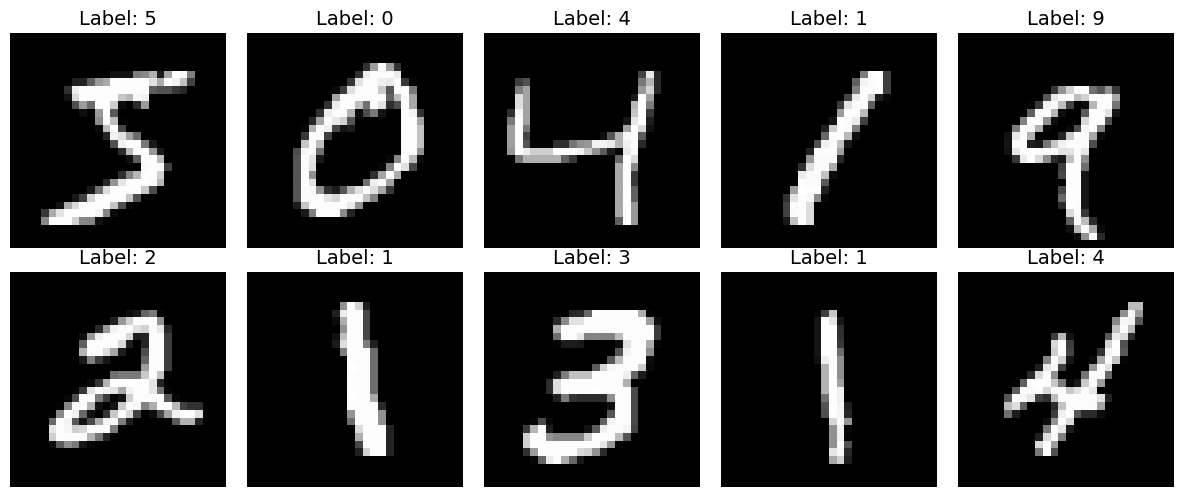

✓ MNIST loaded and visualized successfully!


In [6]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))

for i in range(10):
    img, label = train_dataset[i]
    ax = axes[i // 5, i % 5]
    ax.imshow(img.squeeze(), cmap='gray')
    ax.set_title(f'Label: {label}', fontsize=14)
    ax.axis('off')

plt.tight_layout()
plt.savefig('../results/mnist_samples.png', dpi=150)
plt.show()

print("✓ MNIST loaded and visualized successfully!")

In [8]:
import brevitas.nn as qnn

# Create a simple binary layer
test_layer = qnn.QuantLinear(
    in_features=784,
    out_features=10,
    bias=False,
    weight_bit_width=1  # Binary weights!
)

print(f"✓ Brevitas working!")
print(f"✓ Created QuantLinear layer")
print(f"✓ Weight shape: {test_layer.weight.shape}")

# Test forward pass to verify it works
test_input = torch.randn(1, 784)
test_output = test_layer(test_input)
print(f"✓ Forward pass successful: input {test_input.shape} → output {test_output.shape}")
print(f"✓ Brevitas is ready for BNN training!")

✓ Brevitas working!
✓ Created QuantLinear layer
✓ Weight shape: torch.Size([10, 784])
✓ Forward pass successful: input torch.Size([1, 784]) → output torch.Size([1, 10])
✓ Brevitas is ready for BNN training!


C:\GitRepos\EECE4632\Project\bnn_env\lib\site-packages\torch\_tensor.py:1488: UserWarning: Named tensors and all their associated APIs are an experimental feature and subject to change. Please do not use them for anything important until they are released as stable. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\c10/core/TensorImpl.h:1931.)
  return super().rename(names)
